# Train an Instance Segmentation Model using Mask R-CNN

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/train_instance_segmentation_model.ipynb)

This notebook demonstrates how to train instance segmentation models for object detection (e.g., building detection) using Mask R-CNN. Unlike semantic segmentation, instance segmentation can distinguish between individual objects of the same class, providing separate masks for each instance.

## Install packages

To use the new functionality, ensure the required packages are installed.

In [1]:
#%pip install geoai-py

## Import libraries

In [1]:
import geoai

In [2]:
import geoai
import numpy as np
from pathlib import Path
from PIL import Image
import shutil
from tqdm import tqdm
import os 
from pathlib import Path
import geopandas as gpd
import uuid
import json
import torch
import matplotlib.pyplot as plt
import random

## Download sample data

We'll use the same dataset as the semantic segmentation example for consistency.

In [3]:
# xView2 data paths
images_dir = "/media/data/building_instance_tamu/train/images"
labels_dir = "/media/data/building_instance_tamu/train/targets"

# Output directory for organized training data
output_dir = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train"

print(f"Images directory: {images_dir}")
print(f"Labels directory: {labels_dir}")
print(f"Output directory: {output_dir}")

Images directory: /media/data/building_instance_tamu/train/images
Labels directory: /media/data/building_instance_tamu/train/targets
Output directory: /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train


In [4]:
# Check how many pre-disaster images you have
image_files = list(Path(images_dir).glob("*_pre_disaster.png"))
print(f"Found {len(image_files)} pre-disaster images")

# Show first few filenames
print("\nFirst 5 images:")
for img in image_files[:5]:
    print(f"  - {img.name}")

# Check if corresponding labels exist
missing_labels = []
for img_path in image_files[:5]:
    # Get corresponding label filename
    label_name = img_path.name.replace("_pre_disaster.png", "_pre_disaster_target.png")
    label_path = Path(labels_dir) / label_name
    
    if label_path.exists():
        print(f"✅ {img_path.name} -> {label_name}")
    else:
        print(f"❌ Missing label: {label_name}")
        missing_labels.append(img_path.name)

if missing_labels:
    print(f"\n⚠️  Warning: {len(missing_labels)} images have missing labels")

Found 2799 pre-disaster images

First 5 images:
  - santa-rosa-wildfire_00000027_pre_disaster.png
  - socal-fire_00000593_pre_disaster.png
  - midwest-flooding_00000197_pre_disaster.png
  - hurricane-harvey_00000255_pre_disaster.png
  - palu-tsunami_00000015_pre_disaster.png
✅ santa-rosa-wildfire_00000027_pre_disaster.png -> santa-rosa-wildfire_00000027_pre_disaster_target.png
✅ socal-fire_00000593_pre_disaster.png -> socal-fire_00000593_pre_disaster_target.png
✅ midwest-flooding_00000197_pre_disaster.png -> midwest-flooding_00000197_pre_disaster_target.png
✅ hurricane-harvey_00000255_pre_disaster.png -> hurricane-harvey_00000255_pre_disaster_target.png
✅ palu-tsunami_00000015_pre_disaster.png -> palu-tsunami_00000015_pre_disaster_target.png


In [44]:
# train_raster_url = (
#     "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_rgb_train.tif"
# )
# train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train_buildings.geojson"
# test_raster_url = (
#     "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_test.tif"
# )

In [45]:
# train_raster_path = geoai.download_file(train_raster_url)
# train_vector_path = geoai.download_file(train_vector_url)
# test_raster_path = geoai.download_file(test_raster_url)

## Visualize sample data

Image shape: (1024, 1024, 3)
Label shape: (1024, 1024)
Label unique values: [0 1]
Number of building pixels: 4090
Number of background pixels: 1044486


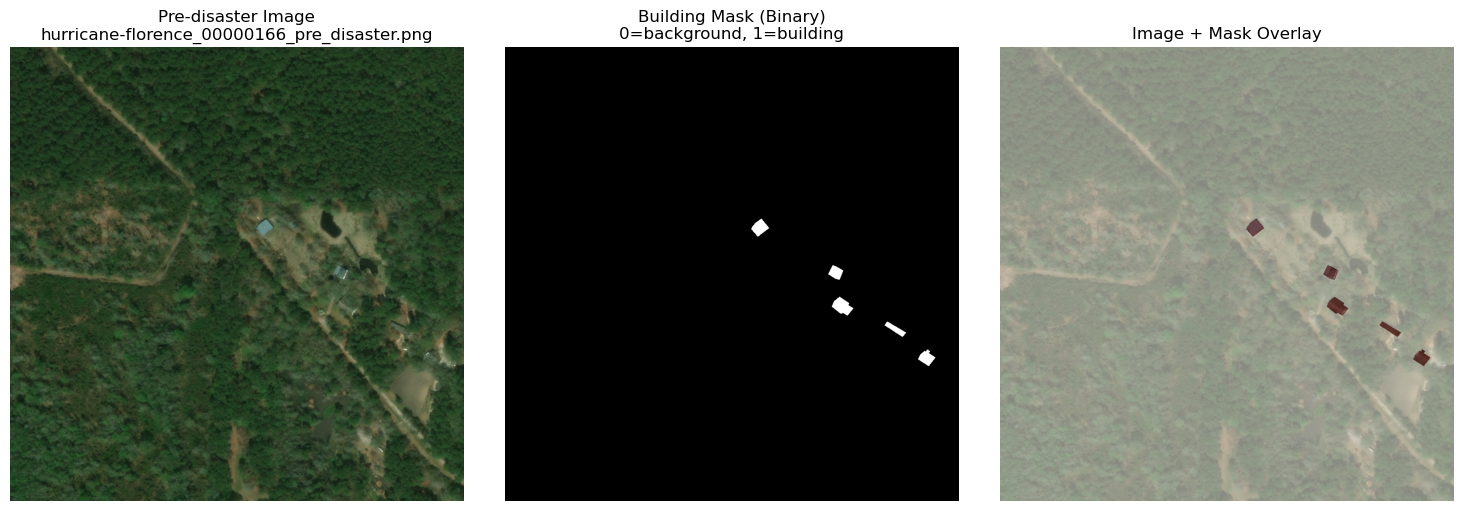

In [7]:
# Visualize first image and its label
sample_img_path = image_files[random.randint(0, len(image_files)-1)]
sample_label_path = Path(labels_dir) / sample_img_path.name.replace("_pre_disaster.png", "_pre_disaster_target.png")

# Load image and label
img = Image.open(sample_img_path)
label = Image.open(sample_label_path)

# Convert to numpy arrays
img_array = np.array(img)
label_array = np.array(label)

print(f"Image shape: {img_array.shape}")
print(f"Label shape: {label_array.shape}")
print(f"Label unique values: {np.unique(label_array)}")
print(f"Number of building pixels: {np.sum(label_array == 1)}")
print(f"Number of background pixels: {np.sum(label_array == 0)}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array)
axes[0].set_title(f"Pre-disaster Image\n{sample_img_path.name}")
axes[0].axis('off')

axes[1].imshow(label_array, cmap='gray')
axes[1].set_title(f"Building Mask (Binary)\n0=background, 1=building")
axes[1].axis('off')

# Overlay
axes[2].imshow(img_array)
axes[2].imshow(label_array, cmap='Reds', alpha=0.5)
axes[2].set_title("Image + Mask Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# geoai.get_raster_info(train_raster_path)

In [ ]:
# style_dict = {
#     "color": "#ff0000",
#     "weight": 2,
#     "opacity": 1,
#     # "fill": True,
#     # "fillColor": "#ffffff",
#     "fillOpacity": 0,
#     # "dashArray": "9"
#     # "clickable": True,
# }
# style_function = lambda x: style_dict

# geoai.view_vector_interactive(
#     train_vector_path, tiles=train_raster_path, style_function=style_function
# )

In [ ]:
# geoai.view_raster(test_raster_path)

## Create training data

We'll create training tiles from the imagery and vector labels.

In [49]:
def prepare_xview2_training_data(images_dir, labels_dir, output_dir):
    """
    Organize xView2 data for geoai training
    
    Input format:
    - images_dir: contains *_pre_disaster.png
    - labels_dir: contains *_pre_disaster_target.png (binary: 0=bg, 1=building)
    
    Output format:
    - output_dir/images: training images
    - output_dir/labels: instance masks (each building gets unique ID)
    """
    
    output_path = Path(output_dir)
    images_out = output_path / "images"
    labels_out = output_path / "labels"
    
    # Create directories
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)
    
    # Get all pre-disaster images
    image_files = list(Path(images_dir).glob("*_pre_disaster.png"))
    
    print(f"Processing {len(image_files)} images...")
    
    prepared_count = 0
    skipped_count = 0
    
    for img_path in tqdm(image_files):
        # Find corresponding label
        label_name = img_path.name.replace("_pre_disaster.png", "_pre_disaster_target.png")
        label_path = Path(labels_dir) / label_name
        
        if not label_path.exists():
            print(f"⚠️  Skipping {img_path.name}: no label found")
            skipped_count += 1
            continue
        
        # Load label
        label = np.array(Image.open(label_path))
        
        # Check if there are any buildings
        if np.sum(label == 1) == 0:
            print(f"⚠️  Skipping {img_path.name}: no buildings in label")
            skipped_count += 1
            continue
        
        # For instance segmentation, we need to separate connected components
        # Each connected building region should have a unique ID
        from scipy import ndimage
        
        # Label connected components (each separate building gets unique ID)
        instance_mask, num_instances = ndimage.label(label == 1)
        
        if num_instances == 0:
            print(f"⚠️  Skipping {img_path.name}: no instances found")
            skipped_count += 1
            continue
        
        # Create output filename (remove disaster suffix for cleaner names)
        base_name = img_path.name.replace("_pre_disaster.png", ".png")
        
        # Copy image
        shutil.copy(img_path, images_out / base_name)
        
        # Save instance mask
        Image.fromarray(instance_mask.astype(np.uint16)).save(labels_out / base_name)
        
        prepared_count += 1
    
    print(f"\n✅ Prepared {prepared_count} training samples")
    print(f"⚠️  Skipped {skipped_count} samples")
    
    return output_dir

# Run preparation
output_dir = prepare_xview2_training_data(
    images_dir=images_dir,
    labels_dir=labels_dir,
    output_dir=output_dir
)

Processing 2799 images...


  0%|          | 9/2799 [00:00<00:32, 86.25it/s]

⚠️  Skipping socal-fire_00000593_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00000371_pre_disaster.png: no buildings in label
⚠️  Skipping hurricane-matthew_00000187_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00000010_pre_disaster.png: no buildings in label
⚠️  Skipping hurricane-harvey_00000118_pre_disaster.png: no buildings in label


  1%|          | 26/2799 [00:00<00:45, 60.73it/s]

⚠️  Skipping socal-fire_00001334_pre_disaster.png: no buildings in label


...

⚠️  Skipping socal-fire_00000467_pre_disaster.png: no buildings in label
⚠️  Skipping midwest-flooding_00000087_pre_disaster.png: no buildings in label


100%|█████████▉| 2794/2799 [00:47<00:00, 68.03it/s]

⚠️  Skipping socal-fire_00000318_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00000186_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00000032_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00001004_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00000611_pre_disaster.png: no buildings in label
⚠️  Skipping socal-fire_00001180_pre_disaster.png: no buildings in label


100%|██████████| 2799/2799 [00:47<00:00, 58.60it/s]


✅ Prepared 2283 training samples
⚠️  Skipped 516 samples


Prepared images: 2283
Prepared labels: 2283

Sample prepared data:
Image shape: (1024, 1024, 3)
Label shape: (1024, 1024)
Number of instances: 8
Instance IDs: [1 2 3 4 5 6 7 8]


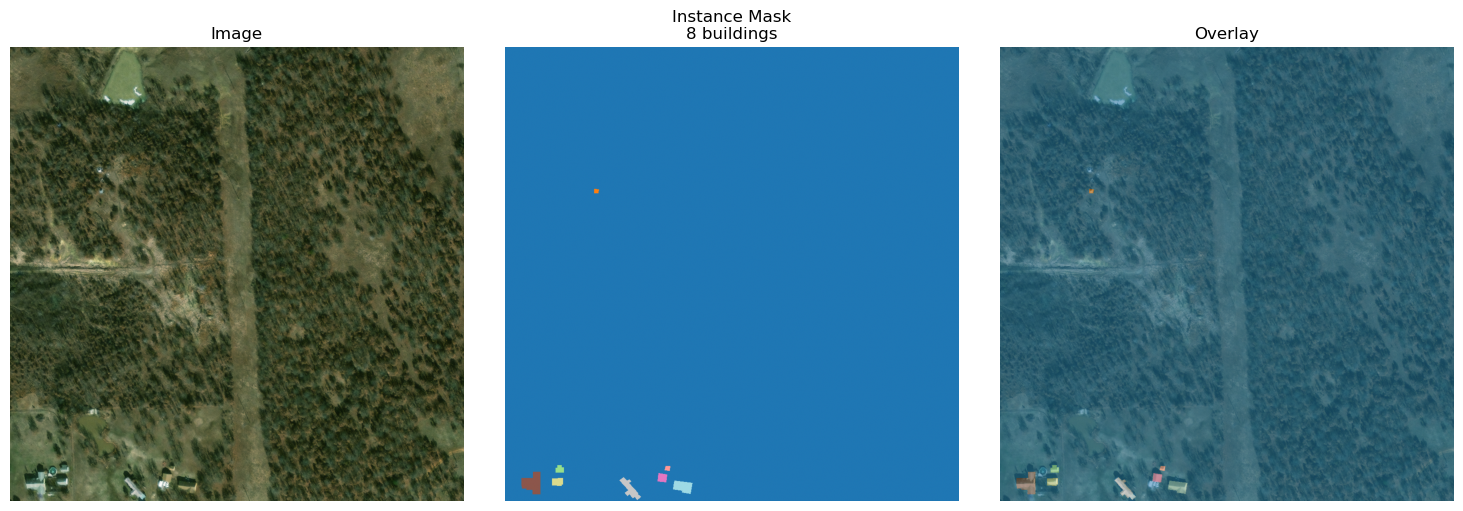

In [54]:
# Check prepared data
prepared_images = list(Path(f"{output_dir}/images").glob("*.png"))
prepared_labels = list(Path(f"{output_dir}/labels").glob("*.png"))

print(f"Prepared images: {len(prepared_images)}")
print(f"Prepared labels: {len(prepared_labels)}")

# Visualize prepared data
if len(prepared_images) > 0:
    random_index = random.randint(0, len(prepared_images)-1)
    sample_img = Image.open(prepared_images[random_index])
    sample_label = Image.open(prepared_labels[random_index])
    
    img_array = np.array(sample_img)
    label_array = np.array(sample_label)
    
    print(f"\nSample prepared data:")
    print(f"Image shape: {img_array.shape}")
    print(f"Label shape: {label_array.shape}")
    print(f"Number of instances: {label_array.max()}")
    print(f"Instance IDs: {np.unique(label_array[label_array > 0])}")
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array)
    axes[0].set_title("Image")
    axes[0].axis('off')
    
    axes[1].imshow(label_array, cmap='tab20')
    axes[1].set_title(f"Instance Mask\n{label_array.max()} buildings")
    axes[1].axis('off')
    
    axes[2].imshow(img_array)
    axes[2].imshow(label_array, cmap='tab20', alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# out_folder = "buildings_instance"
# tiles = geoai.export_geotiff_tiles(
#     in_raster=train_raster_path,
#     out_folder=out_folder,
#     in_class_data=train_vector_path,
#     tile_size=512,
#     stride=256,
#     buffer_radius=0,
# )

## Train instance segmentation model

Now we'll train an instance segmentation model using the `train_instance_segmentation_model` function. This function uses Mask R-CNN, which is specifically designed for instance segmentation tasks.

### Key Differences from Semantic Segmentation:

- **Instance Segmentation**: Identifies and segments each individual object separately (e.g., distinguishes Building A from Building B)
- **Semantic Segmentation**: Only classifies pixels into categories (all buildings are treated as one class)

### Model Architecture:

Mask R-CNN combines:
- **Faster R-CNN** for object detection (bounding boxes)
- **FCN** for pixel-level segmentation (masks)
- **ResNet-50 + FPN** backbone for feature extraction

### Training Parameters:

- `num_classes`: Number of classes including background (default: 2 for background + buildings)
- `num_channels`: Number of input channels (3 for RGB, 4 for RGBN)
- `batch_size`: Typically smaller than semantic segmentation (4-8) due to model complexity
- `num_epochs`: Number of training epochs
- `learning_rate`: Initial learning rate (default: 0.005)
- `val_split`: Fraction of data for validation (default: 0.2)

In [18]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()
# Check GPU memory
print(f"GPU Memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"GPU Memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")

GPU Memory allocated: 0.00 GB
GPU Memory reserved: 0.00 GB


In [ ]:
# Train instance segmentation model - USE ALL DATA FOR TRAINING
geoai.train_instance_segmentation_model(
    images_dir=f"{output_dir}/images",
    labels_dir=f"{output_dir}/labels",
    output_dir=f"{output_dir}/models",
    num_classes=2,          # background + building
    num_channels=3,         # RGB
    batch_size=4,           # Adjust based on GPU memory
    num_epochs=30,          # More epochs for better results
    learning_rate=0.005,
    val_split=0.2,          
    visualize=True,
    verbose=True,
)

TypeError: train_MaskRCNN_model() got an unexpected keyword argument 'resume_from'

### Resume Training

In [5]:
from geoai.train import train_MaskRCNN_model

images_dir = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/images"
labels_dir = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/labels"
model_dir  = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/models"

checkpoint_path = f"{model_dir}/best_model.pth"   # weights-only checkpoint

train_MaskRCNN_model(
    images_dir=images_dir,
    labels_dir=labels_dir,
    output_dir=model_dir,
    input_format="directory",

    # training params
    num_channels=3,
    batch_size=4,
    num_epochs=5,        # extra epochs
    learning_rate=0.001,
    val_split=0.2,
    visualize=True,
    verbose=True,

    # resume settings
    pretrained_model_path=checkpoint_path,
    resume_training=False,     # weights-only resume
)

Using device: cuda
Found 2283 image files and 2283 label files
Training on 1826 images, validating on 457 images
Loading pretrained model from: /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/models/best_model.pth
Pretrained model loaded successfully
Epoch: 1, Batch: 1/457, Loss: 0.4812, Time: 2.97s
Epoch: 1, Batch: 11/457, Loss: 0.4304, Time: 2.75s
Epoch: 1, Batch: 21/457, Loss: 0.9164, Time: 5.10s
Epoch: 1, Batch: 31/457, Loss: 0.5511, Time: 2.75s
Epoch: 1, Batch: 41/457, Loss: 0.8422, Time: 2.61s
Epoch: 1, Batch: 51/457, Loss: 0.9442, Time: 3.01s
Epoch: 1, Batch: 61/457, Loss: 0.6861, Time: 3.54s
Epoch: 1, Batch: 71/457, Loss: 0.7103, Time: 3.14s
Epoch: 1, Batch: 81/457, Loss: 0.5725, Time: 2.85s
Epoch: 1, Batch: 91/457, Loss: 1.0292, Time: 3.07s
Epoch: 1, Batch: 101/457, Loss: 0.6701, Time: 2.73s
Epoch: 1, Batch: 111/457, Loss: 0.5978, Time: 2.75s
Epoch: 1, Batch: 121/457, Loss: 0.7011, Time: 3.48s
Epoch: 1, Batch: 131/457, Loss: 0.6682, Time: 2.98s
Epoch: 1, B

### 251210 After patch updating
Now the code is able to resume training. With full check point updated

In [8]:
import torch
ckpt = torch.load(f"{output_dir}/models/best_model.pth")
print(ckpt.keys())

odict_keys(['backbone.body.conv1.weight', 'backbone.body.bn1.weight', 'backbone.body.bn1.bias', 'backbone.body.bn1.running_mean', 'backbone.body.bn1.running_var', 'backbone.body.layer1.0.conv1.weight', 'backbone.body.layer1.0.bn1.weight', 'backbone.body.layer1.0.bn1.bias', 'backbone.body.layer1.0.bn1.running_mean', 'backbone.body.layer1.0.bn1.running_var', 'backbone.body.layer1.0.conv2.weight', 'backbone.body.layer1.0.bn2.weight', 'backbone.body.layer1.0.bn2.bias', 'backbone.body.layer1.0.bn2.running_mean', 'backbone.body.layer1.0.bn2.running_var', 'backbone.body.layer1.0.conv3.weight', 'backbone.body.layer1.0.bn3.weight', 'backbone.body.layer1.0.bn3.bias', 'backbone.body.layer1.0.bn3.running_mean', 'backbone.body.layer1.0.bn3.running_var', 'backbone.body.layer1.0.downsample.0.weight', 'backbone.body.layer1.0.downsample.1.weight', 'backbone.body.layer1.0.downsample.1.bias', 'backbone.body.layer1.0.downsample.1.running_mean', 'backbone.body.layer1.0.downsample.1.running_var', 'backbone.

In [7]:
# First training, nothing changed
geoai.train_instance_segmentation_model(
    images_dir=f"{output_dir}/images",
    labels_dir=f"{output_dir}/labels",
    output_dir=f"{output_dir}/models",
    num_classes=2,
    num_channels=3,
    batch_size=4,
    num_epochs=1,
    learning_rate=0.005,
    val_split=0.2,
    visualize=True,
    verbose=True,
)

Using device: cuda
Found 2283 image files and 2283 label files
Training on 1826 images, validating on 457 images

===== Epoch 1/1 =====
Epoch: 1, Batch: 1/457, Loss: 7.3751, Time: 2.08s
Epoch: 1, Batch: 11/457, Loss: 1.7891, Time: 2.58s
Epoch: 1, Batch: 21/457, Loss: 1.9378, Time: 2.70s
Epoch: 1, Batch: 31/457, Loss: 1.5371, Time: 2.86s
Epoch: 1, Batch: 41/457, Loss: 1.8731, Time: 2.71s
Epoch: 1, Batch: 51/457, Loss: 1.0709, Time: 3.00s
Epoch: 1, Batch: 61/457, Loss: 1.3658, Time: 2.74s
Epoch: 1, Batch: 71/457, Loss: 1.1204, Time: 2.92s
Epoch: 1, Batch: 81/457, Loss: 1.3169, Time: 2.67s
Epoch: 1, Batch: 91/457, Loss: 0.9033, Time: 2.78s
Epoch: 1, Batch: 101/457, Loss: 1.4095, Time: 2.92s
Epoch: 1, Batch: 111/457, Loss: 1.6472, Time: 2.85s
Epoch: 1, Batch: 121/457, Loss: 1.6554, Time: 2.88s
Epoch: 1, Batch: 131/457, Loss: 1.3238, Time: 2.95s
Epoch: 1, Batch: 141/457, Loss: 1.5649, Time: 3.00s
Epoch: 1, Batch: 151/457, Loss: 1.2185, Time: 2.97s
Epoch: 1, Batch: 161/457, Loss: 1.2742, Tim

KeyboardInterrupt: 

In [5]:
geoai.train_instance_segmentation_model(
    images_dir=f"{output_dir}/images",
    labels_dir=f"{output_dir}/labels",
    output_dir=f"{output_dir}/models",
    num_classes=2,
    num_channels=3,
    batch_size=4,
    num_epochs=60,  # total epochs to run (it resumes from the saved epoch)
    learning_rate=0.003,
    val_split=0.2,
    visualize=True,
    verbose=True,

    pretrained_model_path=f"{output_dir}/models/checkpoint_latest.pth",
    resume_training=True,
)

Using device: cuda
Found 2283 image files and 2283 label files
Training on 1826 images, validating on 457 images
Loading pretrained model from: /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/models/checkpoint_latest.pth
Resuming training from epoch 22
Previous best IoU: 0.6111
Pretrained model loaded successfully

===== Epoch 23/60 =====
Epoch: 23, Batch: 1/457, Loss: 0.9804, Time: 4.00s
Epoch: 23, Batch: 11/457, Loss: 0.7145, Time: 4.23s
Epoch: 23, Batch: 21/457, Loss: 0.9271, Time: 3.64s
Epoch: 23, Batch: 31/457, Loss: 0.5901, Time: 3.68s
Epoch: 23, Batch: 41/457, Loss: 1.0076, Time: 2.86s
Epoch: 23, Batch: 51/457, Loss: 0.5197, Time: 3.16s
Epoch: 23, Batch: 61/457, Loss: 0.6824, Time: 2.80s
Epoch: 23, Batch: 71/457, Loss: 0.6063, Time: 3.00s
Epoch: 23, Batch: 81/457, Loss: 0.6882, Time: 2.74s
Epoch: 23, Batch: 91/457, Loss: 0.4800, Time: 2.88s
Epoch: 23, Batch: 101/457, Loss: 0.8120, Time: 3.02s
Epoch: 23, Batch: 111/457, Loss: 1.0239, Time: 3.04s
Epoch: 23, Ba

In [ ]:
# # Train Mask R-CNN model
# geoai.train_instance_segmentation_model(
#     images_dir=f"{out_folder}/images",
#     labels_dir=f"{out_folder}/labels",
#     output_dir=f"{out_folder}/instance_models",
#     num_classes=2,  # background + building
#     num_channels=3,
#     batch_size=4,
#     num_epochs=10,
#     learning_rate=0.005,
#     val_split=0.2,
#     visualize=True,
#     verbose=True,
# )

## Run inference

Now we'll use the trained model to make predictions on the test image. The `instance_segmentation` function performs sliding window inference to handle large images.

In [20]:
# Define paths
test_images_dir = "/media/data/building_instance_tamu/test/images"
test_output_dir = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks"
model_path = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/models/best_model.pth"

# Create output directory
os.makedirs(test_output_dir, exist_ok=True)

# First, verify test images exist
from pathlib import Path
test_images = list(Path(test_images_dir).glob("*_pre_disaster.png"))
print(f"Found {len(test_images)} test images")

if len(test_images) == 0:
    print("❌ No test images found!")
else:
    # Process each image individually
    print("Running inference on test images...")
    for img_path in test_images:
        output_path = Path(test_output_dir) / img_path.name.replace(".png", "_mask.tif")
        
        print(f"Processing: {img_path.name}")
        geoai.instance_segmentation(
            input_path=str(img_path),
            output_path=str(output_path),
            model_path=model_path,
            num_classes=2,
            num_channels=3,
            window_size=1024,
            overlap=256,
            confidence_threshold=0.5,
            batch_size=4,
        )
    
    print(f"✅ Processed {len(test_images)} images!")
    print(f"Results saved to: {test_output_dir}")

Found 933 test images
Running inference on test images...
Processing: santa-rosa-wildfire_00000133_pre_disaster.png
Processing 1 windows with size 1024x1024 and overlap 256...


4it [00:00,  7.91it/s]               


Collected 12 detections before NMS
After NMS: 3 detections
Instance segmentation completed in 0.51 seconds
Final instances: 3
Saved instance segmentation to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks/santa-rosa-wildfire_00000133_pre_disaster_mask.tif
Processing: santa-rosa-wildfire_00000087_pre_disaster.png
Processing 1 windows with size 1024x1024 and overlap 256...


4it [00:00, 31.07it/s]               

Collected 4 detections before NMS
After NMS: 1 detections
Instance segmentation completed in 0.13 seconds
Final instances: 1
Saved instance segmentation to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks/santa-rosa-wildfire_00000087_pre_disaster_mask.tif
Processing: palu-tsunami_00000120_pre_disaster.png


...

4it [00:00,  8.87it/s]               


Collected 260 detections before NMS
After NMS: 61 detections
Instance segmentation completed in 0.47 seconds
Final instances: 61
Saved instance segmentation to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks/hurricane-michael_00000178_pre_disaster_mask.tif
Processing: socal-fire_00000198_pre_disaster.png
Processing 1 windows with size 1024x1024 and overlap 256...


4it [00:00, 18.09it/s]               


Collected 60 detections before NMS
After NMS: 13 detections
Instance segmentation completed in 0.22 seconds
Final instances: 13
Saved instance segmentation to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks/socal-fire_00000198_pre_disaster_mask.tif
Processing: socal-fire_00000509_pre_disaster.png


KeyboardInterrupt: 

In [ ]:
# # Define paths
# masks_path = "naip_test_instance_prediction.tif"
# model_path = f"{out_folder}/instance_models/best_model.pth"

In [ ]:
# # Run instance segmentation inference
# geoai.instance_segmentation(
#     input_path=test_raster_path,
#     output_path=masks_path,
#     model_path=model_path,
#     num_classes=2,
#     num_channels=3,
#     window_size=512,
#     overlap=256,
#     confidence_threshold=0.5,
#     batch_size=4,
# )

## Adjust confidence threshold (optional)

You can control which predictions to keep by adjusting the confidence threshold. Higher values (e.g., 0.7) will be more conservative and only keep high-confidence detections, while lower values (e.g., 0.3) will be more permissive.

In [ ]:
# # Run inference with higher confidence threshold
# masks_path_high_conf = "naip_test_instance_prediction_high_conf.tif"

# geoai.instance_segmentation(
#     input_path=test_raster_path,
#     output_path=masks_path_high_conf,
#     model_path=model_path,
#     num_classes=2,
#     num_channels=3,
#     window_size=512,
#     overlap=256,
#     confidence_threshold=0.7,  # Higher threshold for more confident predictions
#     batch_size=4,
# )

## Vectorize masks

Convert the predicted mask to vector format for better visualization and analysis.

In [71]:
def vectorize_predictions_with_geoai(masks_dir, output_dir, epsilon=2):
    """
    Vectorize prediction masks using geoai.orthogonalize and save as JSON
    
    Args:
        masks_dir: Directory containing predicted mask TIF files
        output_dir: Directory to save JSON files
        epsilon: Tolerance for orthogonalization (smaller = more detailed)
    """
    
    masks_dir = Path(masks_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Find all mask files
    mask_files = list(masks_dir.glob("*.tif")) + list(masks_dir.glob("*.tiff"))
    
    print(f"Processing {len(mask_files)} mask files...")
    
    for mask_path in mask_files:
        print(f"Processing: {mask_path.name}")
        
        # Create temporary GeoJSON path
        temp_geojson = output_dir / f"temp_{mask_path.stem}.geojson"
        
        try:
            # Use geoai to vectorize and orthogonalize
            gdf = geoai.orthogonalize(
                str(mask_path), 
                str(temp_geojson), 
                epsilon=epsilon
            )
            
            if gdf is None or len(gdf) == 0:
                print(f"  ⚠️  No buildings detected in {mask_path.name}")
                continue
            
            # Load mask to get dimensions
            mask = np.array(Image.open(mask_path))
            
            # Convert GeoDataFrame to JSON format
            xy_features = []
            for idx, row in gdf.iterrows():
                # Get WKT geometry
                wkt_geom = row.geometry.wkt
                
                feature = {
                    "properties": {
                        "feature_type": "building",
                        "uid": str(uuid.uuid4())
                    },
                    "wkt": wkt_geom
                }
                xy_features.append(feature)
            
            # Create output JSON structure
            output_json = {
                "features": {
                    "xy": xy_features,
                    "lng_lat": []  # Empty since we don't have geospatial data
                },
                "metadata": {
                    "original_width": mask.shape[1],
                    "original_height": mask.shape[0],
                    "width": mask.shape[1],
                    "height": mask.shape[0],
                    "img_name": mask_path.stem.replace("_pre_disaster_mask", "_pre_disaster") + ".png"
                }
            }
            
            # Save JSON
            output_path = output_dir / (mask_path.stem.replace("_mask", "") + "_prediction.json")
            with open(output_path, 'w') as f:
                json.dump(output_json, f, indent=2)
            
            print(f"  ✅ Saved {len(xy_features)} buildings to {output_path.name}")
            
            # Clean up temporary GeoJSON
            if temp_geojson.exists():
                temp_geojson.unlink()
                
        except Exception as e:
            print(f"  ❌ Error processing {mask_path.name}: {e}")
            continue

# Run vectorization with orthogonalization
masks_dir = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks"
output_dir = "/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels"

vectorize_predictions_with_geoai(
    masks_dir=masks_dir,
    output_dir=output_dir,
    epsilon=2  # Adjust: smaller = more detailed, larger = more simplified
)

print(f"\n✅ All predictions vectorized and orthogonalized!")
print(f"Results saved to: {output_dir}")

Processing 933 mask files...
Processing: hurricane-florence_00000318_pre_disaster_mask.tif
Processing 41 features...


Converting features:   0%|          | 0/41 [00:00<?, ?shape/s]

Converting features: 100%|██████████| 41/41 [00:00<00:00, 178.64shape/s]


Saving to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels/temp_hurricane-florence_00000318_pre_disaster_mask.geojson...
Done!
  ✅ Saved 39 buildings to hurricane-florence_00000318_pre_disaster_prediction.json
Processing: hurricane-harvey_00000164_pre_disaster_mask.tif
Processing 2 features...


Converting features: 100%|██████████| 2/2 [00:00<00:00, 265.65shape/s]


...

Saving to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels/temp_midwest-flooding_00000000_pre_disaster_mask.geojson...
Done!
  ✅ Saved 19 buildings to midwest-flooding_00000000_pre_disaster_prediction.json
Processing: hurricane-florence_00000133_pre_disaster_mask.tif
Processing 3 features...


Converting features: 100%|██████████| 3/3 [00:00<00:00, 196.55shape/s]


Saving to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels/temp_hurricane-florence_00000133_pre_disaster_mask.geojson...
Done!
  ✅ Saved 2 buildings to hurricane-florence_00000133_pre_disaster_prediction.json
Processing: hurricane-matthew_00000394_pre_disaster_mask.tif
Processing 5 features...


Converting features: 100%|██████████| 5/5 [00:00<00:00, 198.65shape/s]

Saving to /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels/temp_hurricane-matthew_00000394_pre_disaster_mask.geojson...
Done!
  ✅ Saved 4 buildings to hurricane-matthew_00000394_pre_disaster_prediction.json

✅ All predictions vectorized and orthogonalized!
Results saved to: /media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels


In [6]:
# output_vector_path = "naip_test_instance_prediction.geojson"
# gdf = geoai.orthogonalize(masks_path, output_vector_path, epsilon=2)

## Add geometric properties

Calculate area, perimeter, and other geometric properties for each detected building.

In [ ]:
# gdf_props = geoai.add_geometric_properties(gdf, area_unit="m2", length_unit="m")

## Visualize results

Found 815 prediction files

Randomly selected: hurricane-florence_00000076_pre_disaster_prediction.json

✅ Found all files for: hurricane-florence_00000076_pre_disaster
  - Image: hurricane-florence_00000076_pre_disaster.png
  - Ground Truth: hurricane-florence_00000076_pre_disaster.json
  - Prediction: hurricane-florence_00000076_pre_disaster_prediction.json
  - Mask: hurricane-florence_00000076_pre_disaster_mask.tif



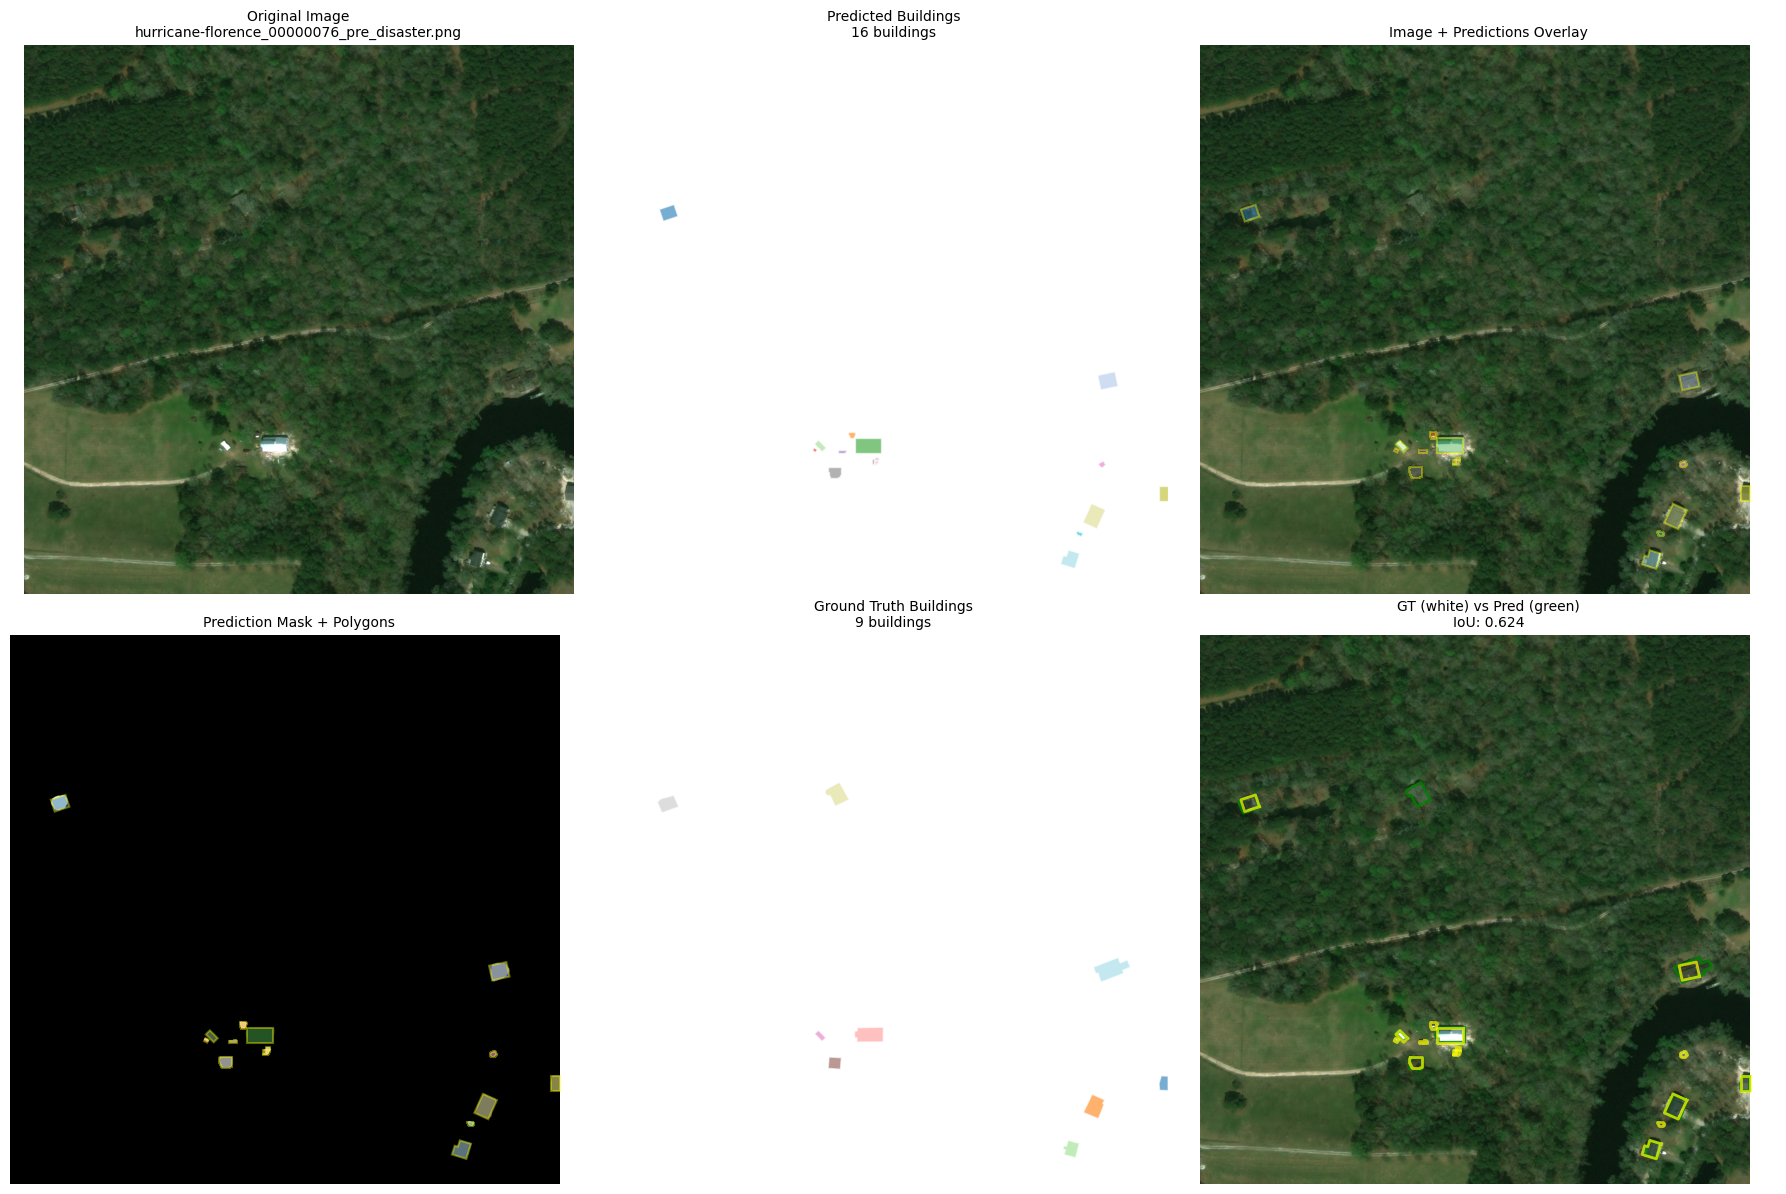


Image: hurricane-florence_00000076_pre_disaster.png
Ground Truth Buildings: 9
Predicted Buildings: 16
Difference: +7
Image size: 1024 x 1024

📊 IoU Metrics:
  Overall IoU (pixel-based): 0.6241 (62.41%)
  Mean Per-Polygon IoU: 0.7112 (71.12%)
  Min IoU: 0.0000
  Max IoU: 0.9075
  Polygons with IoU > 0.5: 8/9



In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from shapely import wkt as shapely_wkt
from shapely.geometry import Polygon
import random
import rasterio

def calculate_polygon_iou(gt_features, pred_features, img_width, img_height):
    """
    Calculate IoU between ground truth and predicted polygons
    
    Args:
        gt_features: Ground truth polygon features
        pred_features: Predicted polygon features
        img_width: Image width
        img_height: Image height
    
    Returns:
        mean_iou: Mean IoU across all polygons
        iou_scores: List of IoU scores for matched polygons
    """
    # Create binary masks for ground truth and predictions
    gt_mask = np.zeros((img_height, img_width), dtype=np.uint8)
    pred_mask = np.zeros((img_height, img_width), dtype=np.uint8)
    
    # Draw ground truth polygons
    from PIL import ImageDraw
    gt_img = Image.new('L', (img_width, img_height), 0)
    draw_gt = ImageDraw.Draw(gt_img)
    
    for feature in gt_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            coords_int = [(int(x), int(y)) for x, y in coords]
            draw_gt.polygon(coords_int, fill=1)
    
    gt_mask = np.array(gt_img)
    
    # Draw predicted polygons
    pred_img = Image.new('L', (img_width, img_height), 0)
    draw_pred = ImageDraw.Draw(pred_img)
    
    for feature in pred_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            coords_int = [(int(x), int(y)) for x, y in coords]
            draw_pred.polygon(coords_int, fill=1)
    
    pred_mask = np.array(pred_img)
    
    # Calculate IoU
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    
    if union == 0:
        iou = 0.0
    else:
        iou = intersection / union
    
    # Also calculate per-polygon IoU using Shapely
    gt_polygons = []
    pred_polygons = []
    
    for feature in gt_features:
        try:
            poly = shapely_wkt.loads(feature['wkt'])
            if poly.is_valid:
                gt_polygons.append(poly)
        except:
            pass
    
    for feature in pred_features:
        try:
            poly = shapely_wkt.loads(feature['wkt'])
            if poly.is_valid:
                pred_polygons.append(poly)
        except:
            pass
    
    # Calculate best match IoU for each ground truth polygon
    per_polygon_ious = []
    for gt_poly in gt_polygons:
        best_iou = 0.0
        for pred_poly in pred_polygons:
            try:
                intersection_area = gt_poly.intersection(pred_poly).area
                union_area = gt_poly.union(pred_poly).area
                if union_area > 0:
                    current_iou = intersection_area / union_area
                    best_iou = max(best_iou, current_iou)
            except:
                pass
        per_polygon_ious.append(best_iou)
    
    mean_per_polygon_iou = np.mean(per_polygon_ious) if per_polygon_ious else 0.0
    
    return iou, mean_per_polygon_iou, per_polygon_ious


def visualize_predictions_with_ground_truth(image_path, pred_json_path, gt_json_path, mask_path):
    """
    Visualize predictions vs ground truth with 6 panels and calculate IoU
    
    Args:
        image_path: Path to the pre-disaster image
        pred_json_path: Path to the prediction JSON file
        gt_json_path: Path to the ground truth JSON file
        mask_path: Path to the prediction mask TIF file
    """
    # Load image
    img = Image.open(image_path)
    img_array = np.array(img)
    
    # Load prediction JSON
    with open(pred_json_path, 'r') as f:
        predictions = json.load(f)
    pred_xy_features = predictions['features']['xy']
    
    # Load ground truth JSON
    with open(gt_json_path, 'r') as f:
        ground_truth = json.load(f)
    gt_xy_features = ground_truth['features']['xy']
    
    # Load mask TIF
    with rasterio.open(mask_path) as src:
        mask_array = src.read(1)
    
    # Calculate IoU
    overall_iou, mean_polygon_iou, per_polygon_ious = calculate_polygon_iou(
        gt_xy_features, pred_xy_features, img_array.shape[1], img_array.shape[0]
    )
    
    # Create figure with 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # ROW 1: PREDICTIONS
    # 1. Original image
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title(f"Original Image\n{Path(image_path).name}", fontsize=10)
    axes[0, 0].axis('off')
    
    # 2. Predicted polygons only
    axes[0, 1].set_xlim(0, img_array.shape[1])
    axes[0, 1].set_ylim(img_array.shape[0], 0)
    axes[0, 1].set_aspect('equal')
    axes[0, 1].set_facecolor('black')
    axes[0, 1].set_title(f"Predicted Buildings\n{len(pred_xy_features)} buildings", fontsize=10)
    axes[0, 1].axis('off')
    
    # Draw predicted polygons
    colors = plt.cm.tab20(np.linspace(0, 1, len(pred_xy_features)))
    for idx, feature in enumerate(pred_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[0, 1].fill(x_coords, y_coords, color=color, alpha=0.6, edgecolor='white', linewidth=1)
    
    # 3. Overlay - Image + Predictions
    axes[0, 2].imshow(img_array)
    axes[0, 2].set_title("Image + Predictions Overlay", fontsize=10)
    axes[0, 2].axis('off')
    
    for idx, feature in enumerate(pred_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[0, 2].fill(x_coords, y_coords, color=color, alpha=0.4, edgecolor='yellow', linewidth=1.5)
    
    # ROW 2: GROUND TRUTH & COMPARISON
    # 4. Mask TIF + Predicted polygons overlay
    axes[1, 0].imshow(mask_array, cmap='gray')
    axes[1, 0].set_title(f"Prediction Mask + Polygons", fontsize=10)
    axes[1, 0].axis('off')
    
    for idx, feature in enumerate(pred_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = colors[idx % len(colors)]
            axes[1, 0].fill(x_coords, y_coords, color=color, alpha=0.4, edgecolor='yellow', linewidth=1.5)
    
    # 5. Ground truth polygons only
    axes[1, 1].set_xlim(0, img_array.shape[1])
    axes[1, 1].set_ylim(img_array.shape[0], 0)
    axes[1, 1].set_aspect('equal')
    axes[1, 1].set_facecolor('black')
    axes[1, 1].set_title(f"Ground Truth Buildings\n{len(gt_xy_features)} buildings", fontsize=10)
    axes[1, 1].axis('off')
    
    # Draw ground truth polygons
    gt_colors = plt.cm.tab20(np.linspace(0, 1, len(gt_xy_features)))
    for idx, feature in enumerate(gt_xy_features):
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            color = gt_colors[idx % len(gt_colors)]
            axes[1, 1].fill(x_coords, y_coords, color=color, alpha=0.6, edgecolor='white', linewidth=1)
    
    # 6. Ground truth (white) vs Predictions (green)
    axes[1, 2].imshow(img_array)
    axes[1, 2].set_title(f"GT (white) vs Pred (green)\nIoU: {overall_iou:.3f}", fontsize=10)
    axes[1, 2].axis('off')
    
    # Draw ground truth in white
    for feature in gt_xy_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            axes[1, 2].plot(x_coords, y_coords, color='green', linewidth=2, alpha=0.8)
    
    # Draw predictions in green (on top)
    for feature in pred_xy_features:
        wkt_str = feature['wkt']
        poly = shapely_wkt.loads(wkt_str)
        if hasattr(poly.exterior, 'coords'):
            coords = list(poly.exterior.coords)
            x_coords = [c[0] for c in coords]
            y_coords = [c[1] for c in coords]
            axes[1, 2].plot(x_coords, y_coords, color='yellow', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics with IoU
    print(f"\n{'='*70}")
    print(f"Image: {Path(image_path).name}")
    print(f"Ground Truth Buildings: {len(gt_xy_features)}")
    print(f"Predicted Buildings: {len(pred_xy_features)}")
    print(f"Difference: {len(pred_xy_features) - len(gt_xy_features):+d}")
    print(f"Image size: {img_array.shape[1]} x {img_array.shape[0]}")
    print(f"\n📊 IoU Metrics:")
    print(f"  Overall IoU (pixel-based): {overall_iou:.4f} ({overall_iou*100:.2f}%)")
    print(f"  Mean Per-Polygon IoU: {mean_polygon_iou:.4f} ({mean_polygon_iou*100:.2f}%)")
    if per_polygon_ious:
        print(f"  Min IoU: {min(per_polygon_ious):.4f}")
        print(f"  Max IoU: {max(per_polygon_ious):.4f}")
        print(f"  Polygons with IoU > 0.5: {sum(1 for x in per_polygon_ious if x > 0.5)}/{len(per_polygon_ious)}")
    print(f"{'='*70}\n")


# Paths
pred_labels_dir = Path("/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels")
gt_labels_dir = Path("/media/data/building_instance_tamu/test/labels")
images_dir = Path("/media/data/building_instance_tamu/test/images")
masks_dir = Path("/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks")

# Get all prediction JSON files
pred_json_files = list(pred_labels_dir.glob("*_prediction.json"))
print(f"Found {len(pred_json_files)} prediction files\n")

# Randomly select one file to visualize
random_index = random.randint(0, len(pred_json_files)-1)
pred_json_path = pred_json_files[random_index]

print(f"Randomly selected: {pred_json_path.name}\n")

# Find corresponding files
base_name = pred_json_path.stem.replace("_prediction", "")
img_path = images_dir / f"{base_name}.png"
gt_json_path = gt_labels_dir / f"{base_name}.json"
mask_path = masks_dir / f"{base_name}_mask.tif"

# Check if all files exist
if all([img_path.exists(), gt_json_path.exists(), mask_path.exists()]):
    print(f"✅ Found all files for: {base_name}")
    print(f"  - Image: {img_path.name}")
    print(f"  - Ground Truth: {gt_json_path.name}")
    print(f"  - Prediction: {pred_json_path.name}")
    print(f"  - Mask: {mask_path.name}\n")
    
    visualize_predictions_with_ground_truth(img_path, pred_json_path, gt_json_path, mask_path)
else:
    print("❌ Missing files:")
    if not img_path.exists():
        print(f"  - Image: {img_path}")
    if not gt_json_path.exists():
        print(f"  - Ground Truth: {gt_json_path}")
    if not mask_path.exists():
        print(f"  - Mask: {mask_path}")

In [ ]:
# geoai.view_raster(
#     masks_path, nodata=0, cmap="tab20", basemap=test_raster_path, backend="ipyleaflet"
# )

In [ ]:
# geoai.view_vector_interactive(gdf_props, column="area_m2", tiles=test_raster_path)

## Filter by area

Filter out small detections that might be noise or artifacts.

In [ ]:
# gdf_filtered = gdf_props[(gdf_props["area_m2"] > 50)]

In [ ]:
# geoai.view_vector_interactive(gdf_filtered, column="area_m2", tiles=test_raster_path)

## Compare predictions with imagery

In [ ]:
# geoai.create_split_map(
#     left_layer=gdf_filtered,
#     right_layer=test_raster_path,
#     left_args={"style": {"color": "red", "fillOpacity": 0.2}},
#     basemap=test_raster_path,
# )

## Model Performance Analysis

Let's examine the training curves and model performance:

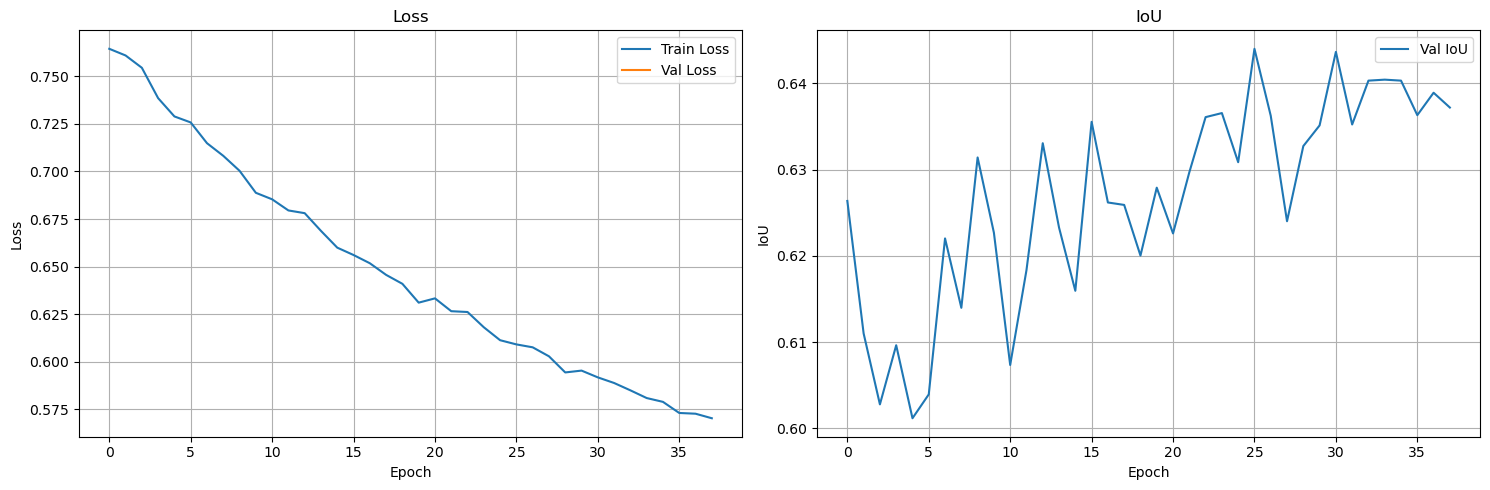


=== Performance Metrics Summary ===
IoU     - Best: 0.6440 | Final: 0.6372
Val Loss - Best: inf | Final: inf



,epoch,train_loss,val_loss,val_iou
0,23,0.764433,inf,0.626363
1,24,0.760935,inf,0.610998
2,25,0.754463,inf,0.602774
3,26,0.738498,inf,0.609632
4,27,0.728899,inf,0.601165
5,28,0.725743,inf,0.603932
6,29,0.714842,inf,0.622015
7,30,0.708201,inf,0.613973
8,31,0.700335,inf,0.631403
9,32,0.688775,inf,0.622677


In [6]:
geoai.plot_performance_metrics(
    history_path="/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

In [12]:
import json
import numpy as np
from PIL import Image, ImageDraw
from pathlib import Path
from shapely import wkt as shapely_wkt
import rasterio

def calculate_all_iou(pred_labels_dir, gt_labels_dir, images_dir, masks_dir):
    """Calculate overall IoU across all predicted vs ground truth labels"""
    
    pred_labels_dir = Path(pred_labels_dir)
    gt_labels_dir = Path(gt_labels_dir)
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)
    
    pred_json_files = sorted(pred_labels_dir.glob("*_prediction.json"))
    print(f"Found {len(pred_json_files)} prediction files\n")
    
    all_ious = []
    all_poly_ious = []
    results = []
    
    for pred_json_path in pred_json_files:
        base = pred_json_path.stem.replace("_prediction", "")
        
        img_path = images_dir / f"{base}.png"
        gt_json_path = gt_labels_dir / f"{base}.json"
        mask_path = masks_dir / f"{base}_mask.tif"
        
        # Check if all files exist
        if not all(p.exists() for p in [img_path, gt_json_path, mask_path]):
            print(f"⚠️  Skipping {base} - missing files")
            continue
        
        try:
            # Load predictions and ground truth
            with open(pred_json_path) as f:
                pred = json.load(f)["features"]["xy"]
            with open(gt_json_path) as f:
                gt = json.load(f)["features"]["xy"]
            
            # Get image dimensions
            img = Image.open(img_path)
            img_w, img_h = img.size
            
            # Calculate IoU
            iou, mean_poly_iou, per_poly = calculate_polygon_iou(gt, pred, img_w, img_h)
            
            all_ious.append(iou)
            all_poly_ious.append(mean_poly_iou)
            
            results.append({
                "image": base,
                "gt_count": len(gt),
                "pred_count": len(pred),
                "overall_iou": iou,
                "mean_poly_iou": mean_poly_iou,
                "per_poly_ious": per_poly
            })
            
            print(f"✅ {base}: Overall IoU={iou:.4f}, Mean Poly IoU={mean_poly_iou:.4f} (GT: {len(gt)}, Pred: {len(pred)})")
            
        except Exception as e:
            print(f"❌ Error processing {base}: {e}")
            continue
    
    # Calculate aggregate statistics
    print(f"\n{'='*70}")
    print(f"MASK R-CNN OVERALL STATISTICS ({len(results)} images)")
    print(f"{'='*70}")
    print(f"Mean Overall IoU:     {np.mean(all_ious):.4f} ± {np.std(all_ious):.4f}")
    print(f"Mean Per-Poly IoU:    {np.mean(all_poly_ious):.4f} ± {np.std(all_poly_ious):.4f}")
    print(f"Min Overall IoU:      {np.min(all_ious):.4f}")
    print(f"Max Overall IoU:      {np.max(all_ious):.4f}")
    print(f"Median Overall IoU:   {np.median(all_ious):.4f}")
    
    return results, all_ious, all_poly_ious

# Run it for Mask R-CNN predictions
results, all_ious, all_poly_ious = calculate_all_iou(
    pred_labels_dir="/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/labels",
    gt_labels_dir="/media/data/building_instance_tamu/test/labels",
    images_dir="/media/data/building_instance_tamu/test/images",
    masks_dir="/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/masks"
)

# Save results to CSV
import pandas as pd
df_results = pd.DataFrame([
    {
        "image": r["image"],
        "gt_count": r["gt_count"],
        "pred_count": r["pred_count"],
        "overall_iou": r["overall_iou"],
        "mean_poly_iou": r["mean_poly_iou"]
    }
    for r in results
])
df_results.to_csv("/media/data/building_instance_tamu/Mask_R-CNN_BuildingInstance_Train/test/iou_results.csv", index=False)
print(f"\n✅ Results saved to iou_results.csv")

Found 815 prediction files

✅ guatemala-volcano_00000003_pre_disaster: Overall IoU=0.6859, Mean Poly IoU=0.7060 (GT: 3, Pred: 3)
✅ guatemala-volcano_00000005_pre_disaster: Overall IoU=0.9120, Mean Poly IoU=0.8765 (GT: 1, Pred: 1)
✅ guatemala-volcano_00000009_pre_disaster: Overall IoU=0.8937, Mean Poly IoU=0.8430 (GT: 4, Pred: 7)
✅ guatemala-volcano_00000011_pre_disaster: Overall IoU=0.0000, Mean Poly IoU=0.0000 (GT: 1, Pred: 1)
✅ guatemala-volcano_00000021_pre_disaster: Overall IoU=0.2563, Mean Poly IoU=0.5274 (GT: 23, Pred: 72)
✅ hurricane-florence_00000004_pre_disaster: Overall IoU=0.7343, Mean Poly IoU=0.6715 (GT: 84, Pred: 102)
✅ hurricane-florence_00000005_pre_disaster: Overall IoU=0.7720, Mean Poly IoU=0.6776 (GT: 77, Pred: 106)
✅ hurricane-florence_00000007_pre_disaster: Overall IoU=0.5894, Mean Poly IoU=0.5374 (GT: 16, Pred: 38)
✅ hurricane-florence_00000013_pre_disaster: Overall IoU=0.7902, Mean Poly IoU=0.7022 (GT: 50, Pred: 63)
✅ hurricane-florence_00000019_pre_disaster: Ove

## Instance vs Semantic Segmentation Comparison

### When to use Instance Segmentation:

1. **Individual object analysis**: When you need to count, measure, or analyze individual objects
2. **Overlapping objects**: When objects of the same class may overlap or touch
3. **Object tracking**: When tracking individual objects across frames or images
4. **Spatial relationships**: When analyzing relationships between individual objects

### When to use Semantic Segmentation:

1. **Area coverage**: When you only need to know what percentage of an image contains a certain class
2. **Land cover mapping**: For continuous features like vegetation, water, roads
3. **Simpler models**: When you want faster training and inference
4. **Pixel-level classification**: When object boundaries are less important

### Model Outputs:

**Instance Segmentation (Mask R-CNN)**:
- Bounding boxes for each object
- Confidence scores for each detection
- Binary mask for each individual object
- Class label for each object

**Semantic Segmentation**:
- Single multi-class mask covering the entire image
- Probability map (optional)
- No distinction between individual objects

### Performance Considerations:

| Aspect | Instance Segmentation | Semantic Segmentation |
|--------|----------------------|----------------------|
| **Training Time** | Slower (more complex model) | Faster |
| **Inference Time** | Slower | Faster |
| **Memory Usage** | Higher | Lower |
| **Accuracy** | Better for distinct objects | Better for continuous classes |
| **Typical Batch Size** | 2-8 | 8-32 |

### Metrics:

**Instance Segmentation Metrics**:
- **AP (Average Precision)**: Precision at different IoU thresholds
- **AP@0.5**: Average Precision at IoU threshold of 0.5
- **AP@0.75**: Average Precision at IoU threshold of 0.75
- **AR (Average Recall)**: Recall averaged across IoU thresholds

**Semantic Segmentation Metrics**:
- **IoU (Intersection over Union)**: Overlap between prediction and ground truth
- **Dice Score**: Similar to IoU but more sensitive to small objects
- **Pixel Accuracy**: Percentage of correctly classified pixels

## Batch Processing (Optional)

If you have multiple images to process, you can use the batch inference function:

In [ ]:
# Uncomment to process multiple images
# geoai.instance_segmentation_batch(
#     input_dir="path/to/input/images",
#     output_dir="path/to/output/masks",
#     model_path=model_path,
#     num_classes=2,
#     num_channels=3,
#     window_size=512,
#     overlap=256,
#     confidence_threshold=0.5,
#     batch_size=4,
# )

## Advanced: Multi-channel Input (RGBN)

If your imagery includes a near-infrared (NIR) band, you can train with 4 channels:

In [ ]:
# Example for 4-channel (RGBN) imagery
# geoai.train_instance_segmentation_model(
#     images_dir=f"{out_folder}/images",
#     labels_dir=f"{out_folder}/labels",
#     output_dir=f"{out_folder}/instance_models_rgbn",
#     num_classes=2,
#     num_channels=4,  # RGB + NIR
#     batch_size=4,
#     num_epochs=10,
#     learning_rate=0.005,
#     val_split=0.2,
#     verbose=True,
# )